# Лабораторная работа №2
## Обнаружение аномалий и выбросов в данных

**Датасет:** `Housing.csv`

Цель: выполнить профилирование числового датасета, визуально исследовать выбросы, проверить нормальность распределений, применить Z-score и IQR, а затем выполнить многомерное обнаружение аномалий по расстояниям до ближайших соседей.

In [45]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

df = pd.read_csv("data/Housing.csv")
display(df.head())

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


## Задание 1. Загрузка и профилирование данных

In [ ]:
print("Размер датасета:", df.shape)
df.info()

print("\nОписательная статистика:")
display(df.describe(include="all").T)

print("\nПропуски:")
display(df.isna().sum().to_frame("missing"))

print("\nДубликаты:", df.duplicated().sum())

nc = df.select_dtypes(include=np.number).columns.tolist()
print("\nЧисловые признаки:", nc)

display(pd.DataFrame({
    "min": df[nc].min(),
    "max": df[nc].max(),
    "range": df[nc].max() - df[nc].min()
}))

### Визуальный анализ

Для детального анализа выбраны признаки **`price`** и **`area`**. Для каждого строятся гистограмма и boxplot.

In [ ]:
for col in ["price", "area"]:
    fig, ax = plt.subplots()
    ax.hist(df[col].dropna(), bins=30, edgecolor="black")
    ax.set_title(f"Гистограмма: {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Частота")
    plt.show()

    fig, ax = plt.subplots()
    ax.boxplot(df[col].dropna(), vert=False)
    ax.set_title(f"Boxplot: {col}")
    ax.set_xlabel(col)
    plt.show()

### Вывод

Гистограммы показывают форму распределений, а boxplot позволяет увидеть медиану, квартильный диапазон и потенциальные экстремальные наблюдения. Точки за пределами «усов» рассматриваются как кандидаты на выбросы и далее проверяются статистическими методами.

## Задание 2. Проверка нормальности распределения

In [32]:
sf = ["price", "area"] if "price" in df.columns and "area" in df.columns else nc[:2]

rows = []
for col in sf:
    x = df[col].dropna()
    sh = stats.shapiro(x)
    rows.append({
        "feature": col,
        "mean": x.mean(),
        "median": x.median(),
        "std": x.std(),
        "skewness": x.skew(),
        "kurtosis": x.kurtosis(),
        "shapiro_stat": sh.statistic,
        "p_value": sh.pvalue
    })

nr = pd.DataFrame(rows)
display(nr)

,feature,mean,median,std,skewness,kurtosis,shapiro_stat,p_value
0,price,"4,766,729.248","4,340,000.000","1,870,439.616",1.212,1.960,0.922,0.000
1,area,"5,150.541","4,600.000","2,170.141",1.321,2.751,0.911,0.000


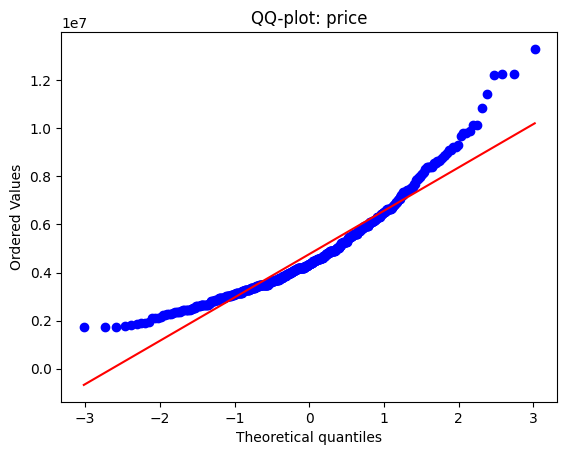

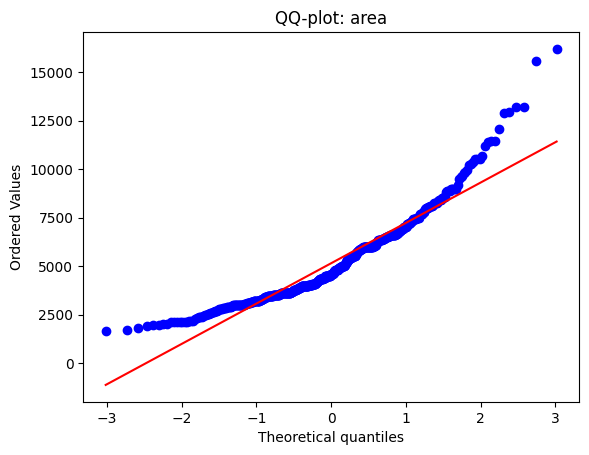

In [33]:
for col in sf:
    x = df[col].dropna()
    fig = plt.figure()
    ax = fig.add_subplot(111)
    stats.probplot(x, dist="norm", plot=ax)
    ax.set_title(f"QQ-plot: {col}")
    plt.show()

### Критерий Шапиро–Уилка

**H0:** выборка подчиняется нормальному распределению.

**H1:** выборка не подчиняется нормальному распределению.

Уровень значимости: **α = 0.05**.

Если `p-value < 0.05`, H0 отвергается; если `p-value >= 0.05`, оснований отвергать H0 нет.

In [34]:
alpha = 0.05
nr["decision"] = np.where(
    nr["p_value"] < alpha,
    "Отклоняем H0",
    "Нет оснований отвергать H0"
)
display(nr[["feature", "shapiro_stat", "p_value", "decision"]])

,feature,shapiro_stat,p_value,decision
0,price,0.922,0.000,Отклоняем H0
1,area,0.911,0.000,Отклоняем H0


### Вывод

Решение о нормальности принимается отдельно для каждого признака по p-value критерия Шапиро–Уилка и по характеру отклонений на QQ-графике.

## Задание 3. Обнаружение выбросов статистическими методами

### 3.1. Z-score для `price`

Критерий выброса: **|Z| > 3**.

Количество выбросов: 6


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished


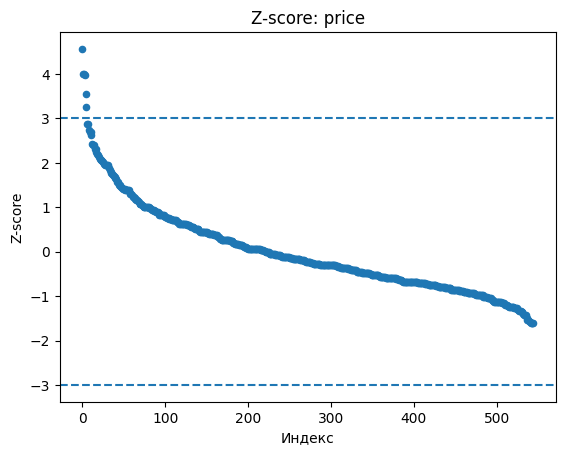

In [35]:
x = df["price"].dropna()
z = pd.Series(stats.zscore(x), index=x.index)
io = df.loc[z.abs() > 3].copy()

print("Количество выбросов:", len(io))
display(io)

fig, ax = plt.subplots()
ax.scatter(z.index, z.values, s=20)
ax.axhline(3, linestyle="--")
ax.axhline(-3, linestyle="--")
ax.set_title("Z-score: price")
ax.set_xlabel("Индекс")
ax.set_ylabel("Z-score")
plt.show()

### 3.2. Метод IQR для `price`

In [36]:
q1 = df["price"].quantile(0.25)
q3 = df["price"].quantile(0.75)
iq = q3 - q1
lo = q1 - 1.5 * iq
up = q3 + 1.5 * iq

iq_mask = (df["price"] < lo) | (df["price"] > up)
iq_outliers = df.loc[iq_mask].copy()

print("Q1:", q1)
print("Q3:", q3)
print("IQR:", iq)
print("Нижняя граница:", lo)
print("Верхняя граница:", up)
print("Количество выбросов:", len(iq_outliers))
display(iq_outliers)

Q1: 3430000.0
Q3: 5740000.0
IQR: 2310000.0
Нижняя граница: -35000.0
Верхняя граница: 9205000.0
Количество выбросов: 15


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


,method,outlier_count
0,Z-score,6
1,IQR,15


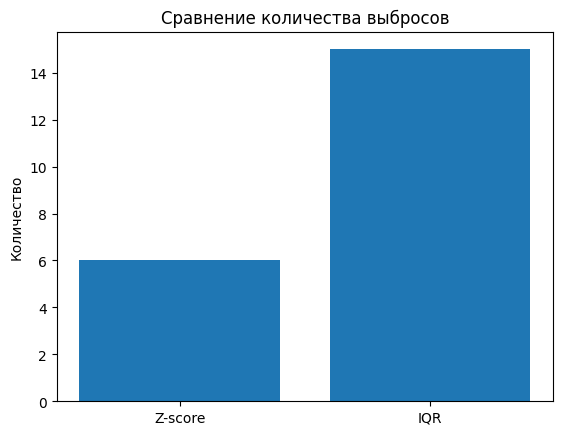

In [37]:
cmp = pd.DataFrame({
    "method": ["Z-score", "IQR"],
    "outlier_count": [len(io), len(iq_outliers)]
})
display(cmp)

fig, ax = plt.subplots()
ax.bar(cmp["method"], cmp["outlier_count"])
ax.set_title("Сравнение количества выбросов")
ax.set_ylabel("Количество")
plt.show()

### Вывод

Z-score определяет экстремальные значения относительно среднего и стандартного отклонения. IQR использует квартильный диапазон и менее зависит от экстремальных наблюдений. Количество найденных выбросов может различаться.

## Задание 4. Метод локальной плотности / ближайших соседей

Для многомерного анализа используются все числовые признаки. Перед расчётом расстояний выполняется `StandardScaler`.

Для `k = 5, 7, 9, 10` вычисляется среднее расстояние до k ближайших соседей. Верхние 5% значений считаются аномалиями.

In [38]:
nf = df.select_dtypes(include=np.number).columns.tolist()
X = df[nf].copy()

scaler = StandardScaler()
xs = scaler.fit_transform(X)

print("Признаки:", nf)
print("Размер матрицы:", xs.shape)

Признаки: ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']
Размер матрицы: (545, 6)


### Евклидово расстояние

In [39]:
er = []
em = {}

for k in [5, 7, 9, 10]:
    nn = NearestNeighbors(n_neighbors=k+1, metric="euclidean")
    nn.fit(xs)
    distances, _ = nn.kneighbors(xs)
    md = distances[:, 1:k+1].mean(axis=1)
    th = np.quantile(md, 0.95)
    an = md >= th

    em[k] = md
    er.append({
        "k": k,
        "th_95%": th,
        "an_count": int(an.sum()),
        "an_share_%": an.mean() * 100
    })

euclidean_summary = pd.DataFrame(er)
display(euclidean_summary)

,k,th_95%,an_count,an_share_%
0,5,1.847,28,5.138
1,7,1.951,28,5.138
2,9,2.018,28,5.138
3,10,2.047,28,5.138


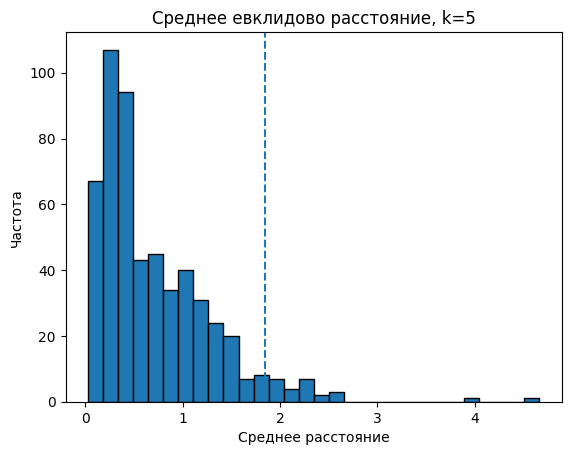

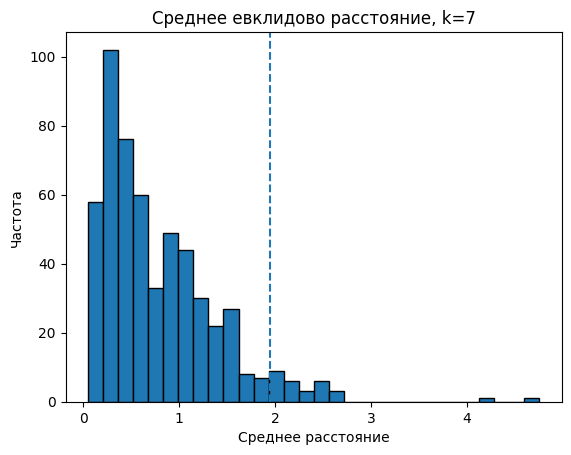

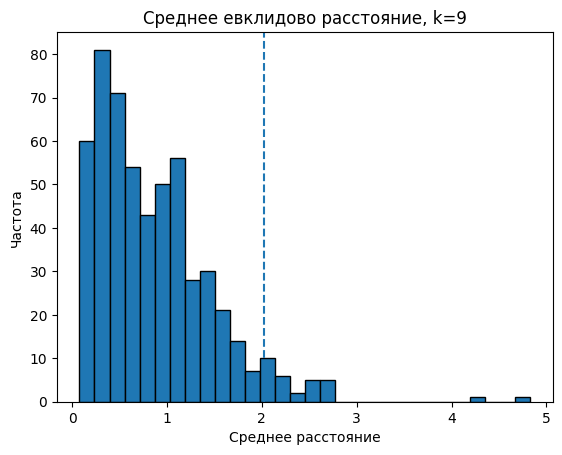

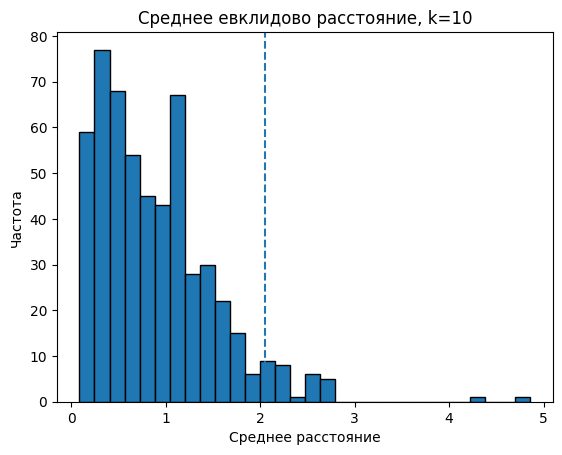

In [40]:
for k, values in em.items():
    fig, ax = plt.subplots()
    ax.hist(values, bins=30, edgecolor="black")
    ax.axvline(np.quantile(values, 0.95), linestyle="--")
    ax.set_title(f"Среднее евклидово расстояние, k={k}")
    ax.set_xlabel("Среднее расстояние")
    ax.set_ylabel("Частота")
    plt.show()

### Манхэттенское расстояние

In [41]:
mr = []
mm = {}

for k in [5, 7, 9, 10]:
    nn = NearestNeighbors(n_neighbors=k+1, metric="manhattan")
    nn.fit(xs)
    distances, _ = nn.kneighbors(xs)
    md = distances[:, 1:k+1].mean(axis=1)
    th = np.quantile(md, 0.95)
    an = md >= th

    mm[k] = md
    mr.append({
        "k": k,
        "th_95%": th,
        "an_count": int(an.sum()),
        "an_share_%": an.mean() * 100
    })

manhattan_summary = pd.DataFrame(mr)
display(manhattan_summary)

,k,th_95%,an_count,an_share_%
0,5,2.594,28,5.138
1,7,2.851,28,5.138
2,9,3.053,28,5.138
3,10,3.137,28,5.138


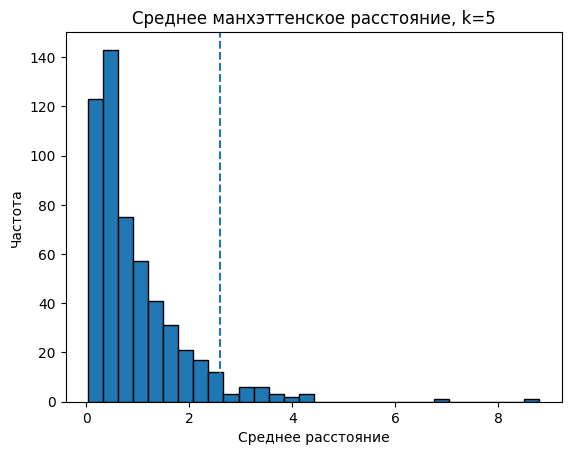

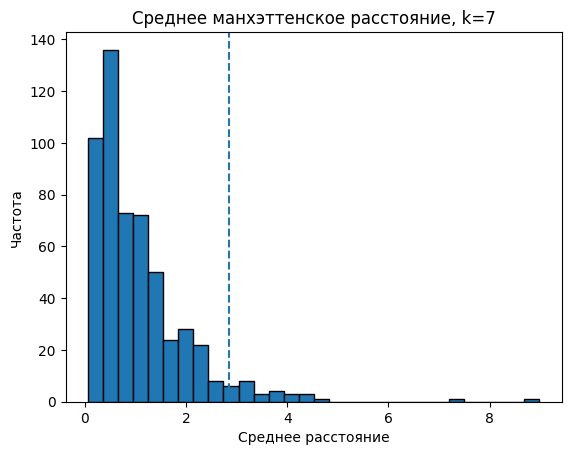

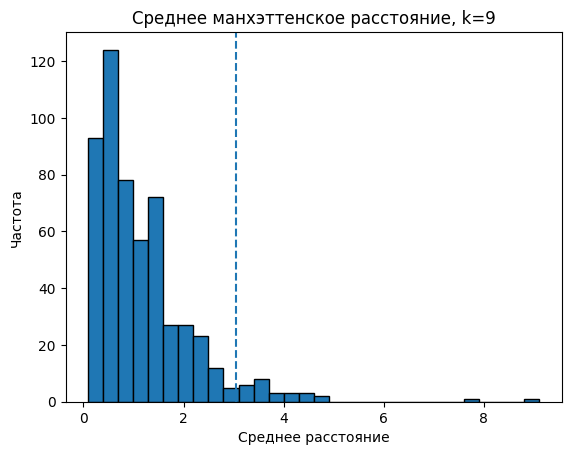

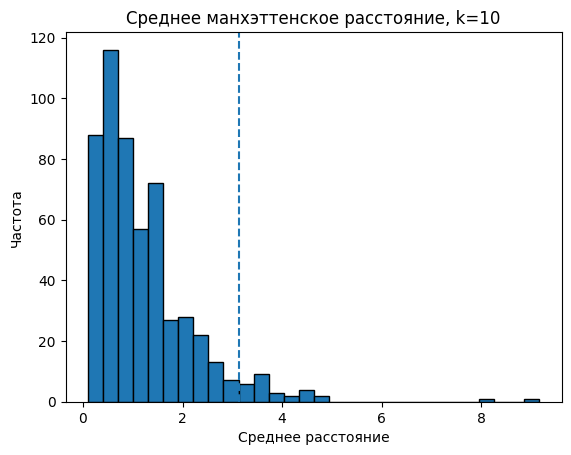

In [42]:
for k, values in mm.items():
    fig, ax = plt.subplots()
    ax.hist(values, bins=30, edgecolor="black")
    ax.axvline(np.quantile(values, 0.95), linestyle="--")
    ax.set_title(f"Среднее манхэттенское расстояние, k={k}")
    ax.set_xlabel("Среднее расстояние")
    ax.set_ylabel("Частота")
    plt.show()

### Scatter plot аномалий

Для визуализации используются `area` и `price`.

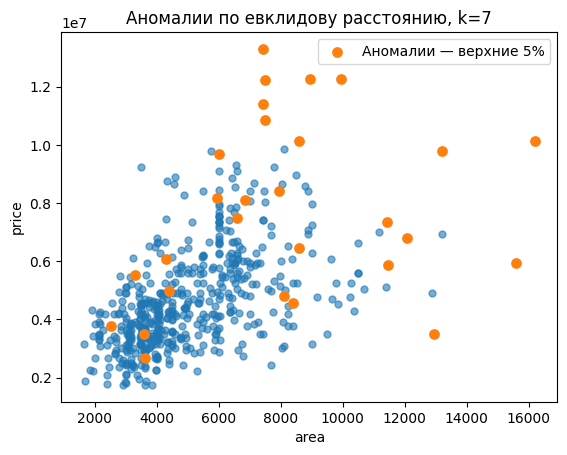

In [43]:
vk = 7
d = em[vk]
th = np.quantile(d, 0.95)
mask = d >= th

fig, ax = plt.subplots()
ax.scatter(df["area"], df["price"], s=25, alpha=0.6)
ax.scatter(
    df.loc[mask, "area"],
    df.loc[mask, "price"],
    s=45,
    label="Аномалии — верхние 5%"
)
ax.set_xlabel("area")
ax.set_ylabel("price")
ax.set_title(f"Аномалии по евклидову расстоянию, k={vk}")
ax.legend()
plt.show()

### Анализ устойчивости при изменении k

In [44]:
st = euclidean_summary.merge(
    manhattan_summary,
    on="k",
    suffixes=("_euclidean", "_manhattan")
)
display(st)

,k,th_95%_euclidean,an_count_euclidean,an_share_%_euclidean,th_95%_manhattan,an_count_manhattan,an_share_%_manhattan
0,5,1.847,28,5.138,2.594,28,5.138
1,7,1.951,28,5.138,2.851,28,5.138
2,9,2.018,28,5.138,3.053,28,5.138
3,10,2.047,28,5.138,3.137,28,5.138


## Итоговые выводы

В работе выполнено профилирование `Housing.csv`, визуальный анализ двух числовых признаков, проверка нормальности критерием Шапиро–Уилка, обнаружение выбросов методами Z-score и IQR, а также многомерный поиск аномалий на основе расстояний до ближайших соседей.

Для метрического анализа признаки стандартизированы. Рассмотрены евклидово и манхэттенское расстояния и значения `k = 5, 7, 9, 10`. Верхние 5% объектов по средней дистанции интерпретируются как потенциальные аномалии.

Статистически необычное значение не обязательно является ошибкой, поэтому решение об удалении или изменении наблюдений должно учитывать предметную область.